In [1]:
%load_ext autoreload
%autoreload 2

Failed to read module file 'C:\Users\victo\miniconda3\Lib\shlex.py' for module 'shlex': UnicodeDecodeError
Traceback (most recent call last):
  File "c:\Users\victo\Desktop\University\Research\qml-quansistor-entropy\.venv\Lib\site-packages\IPython\core\extensions.py", line 62, in load_extension
    return self._load_extension(module_str)
           ~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^
  File "c:\Users\victo\Desktop\University\Research\qml-quansistor-entropy\.venv\Lib\site-packages\IPython\core\extensions.py", line 77, in _load_extension
    mod = import_module(module_str)
  File "C:\Users\victo\miniconda3\Lib\importlib\__init__.py", line 88, in import_module
    return _bootstrap._gcd_import(name[level:], package, level)
           ~~~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "<frozen importlib._bootstrap>", line 1387, in _gcd_import
  File "<frozen importlib._bootstrap>", line 1360, in _find_and_load
  File "<frozen importlib._bootstrap>", line 1324, in _find_and_load_unloc

In [2]:
import logging
import sys

from pathlib import Path
project_root = Path().resolve().parent
sys.path.append(str(project_root))

from scripts import (
    generate_dataset,
    generate_pred_datasets,
    optuna_search,
    predictions,
    training,
)
from src.utils import configure_logger

import pandas as pd
from qqe.src.experiments.plotting import view_correlation

logger = logging.getLogger(__name__)
configure_logger(logging.INFO, logging.INFO)

True

In [3]:
from typing import Any

from qqe.src.GNN.training.utils import collect_dataset_paths
from qqe.src.GNN.training.runners import MODEL_REGISTRY
from qqe.src.GNN.training.train_config import TrainConfig

from collections.abc import Callable
Loader = Callable[..., Any]

In [4]:
model_type="gnn"
epochs = 30
lr = 1e-4
loss_type = "huber"   # "mse" | "huber"
batch_size = 32
training_mode = "per_family"  # "global" | "per_family"
family = "clifford"  # required if training_mode == "per_family"
target = "sre"
data_dir = "../outputs/data/dataset"
model_save_path = "../outputs/models/clifford_model_gnn.pt"
show_progress=True
show_val_progress=False
log_every_n_batches=10
heartbeat_secs=60.0
epoch_time_warning_secs=600.0

In [6]:
def make_dataset_loaders(
    model_type: str,
    epochs: int,
    lr: float,
    loss_type: str,
    batch_size: int,
    training_mode: str,
    family: str,
    target: str,
    data_dir: str,
    model_save_path: str,
    show_progress: bool = True,
    show_val_progress: bool = False,
    log_every_n_batches: int = 10,
    heartbeat_secs: float = 60.0,
    epoch_time_warning_secs: float = 600.0,
):
    cfg = TrainConfig(
        epochs=epochs,
        lr=lr,
        loss_type=loss_type,
        batch_size=batch_size,
        training_mode=training_mode,
        family=family,
        target=target,
        show_progress=show_progress,
        show_val_progress=show_val_progress,
        log_batch_loss_every=log_every_n_batches,
        heartbeat=heartbeat_secs,
        epoch_warning=epoch_time_warning_secs,
    )

    train_paths = collect_dataset_paths(
        data_dir,
        family=family if training_mode == "per_family" else None,
        split="target",
    )
    if not train_paths:
        raise RuntimeError("No data paths found.")
    logger.info(f"Found {len(train_paths)} data paths.")
    logger.info("Data paths collected.")

    spec = MODEL_REGISTRY[model_type]
    logger.info(f"Building loaders and model for model_type={model_type}...")

    loader_fn: Loader = spec["build_loaders"]
    returns_nodes_dim: bool = spec.get("returns_nodes_dim", False)
    if returns_nodes_dim:
        train_loader, val_loader, test_loader, node_in_dim, global_in_dim, base_dataset = loader_fn(
            train_paths,
            batch_size=cfg.batch_size,
            seed=cfg.seed,
            train_split=cfg.train_split,
            val_split=cfg.val_split,
            global_feature_variant=cfg.global_feature_variant,
            node_feature_variant=cfg.node_feature_backend_variant,
            family_projection=family,
        )
    else:
        train_loader, val_loader, test_loader, global_in_dim, base_dataset = loader_fn(
            train_paths,
            batch_size=cfg.batch_size,
            seed=cfg.seed,
            train_split=cfg.train_split,
            val_split=cfg.val_split,
            global_feature_variant=cfg.global_feature_variant,
            node_feature_variant=cfg.node_feature_backend_variant,
            family_projection=family,
        )
        node_in_dim = global_in_dim

    return train_loader, val_loader, test_loader, node_in_dim, global_in_dim, base_dataset

In [8]:
train_loader_cliff, val_loader_cliff, test_loader_cliff, node_in_dim_cliff, global_in_dim_cliff, base_dataset_cliff = make_dataset_loaders(model_type, epochs, lr, loss_type, batch_size, training_mode, "clifford", target, data_dir, model_save_path, show_progress, show_val_progress, log_every_n_batches, heartbeat_secs, epoch_time_warning_secs)
train_loader_haar, val_loader_haar, test_loader_haar, node_in_dim_haar, global_in_dim_haar, base_dataset_haar = make_dataset_loaders(model_type, epochs, lr, loss_type, batch_size, training_mode, "haar", target, data_dir, model_save_path, show_progress, show_val_progress, log_every_n_batches, heartbeat_secs, epoch_time_warning_secs)
train_loader_random, val_loader_random, test_loader_random, node_in_dim_random, global_in_dim_random, base_dataset_random = make_dataset_loaders(model_type, epochs, lr, loss_type, batch_size, training_mode, "random", target, data_dir, model_save_path, show_progress, show_val_progress, log_every_n_batches, heartbeat_secs, epoch_time_warning_secs)
train_loader_quansistor, val_loader_quansistor, test_loader_quansistor, node_in_dim_quansistor, global_in_dim_quansistor, base_dataset_quansistor = make_dataset_loaders(model_type, epochs, lr, loss_type, batch_size, training_mode, "quansistor", target, data_dir, model_save_path, show_progress, show_val_progress, log_every_n_batches, heartbeat_secs, epoch_time_warning_secs)

2026-05-19 10:27:44,482 - __main__ - INFO - Found 35700 data paths.
2026-05-19 10:27:44,483 - __main__ - INFO - Data paths collected.
2026-05-19 10:27:44,484 - __main__ - INFO - Building loaders and model for model_type=gnn...
2026-05-19 10:30:40,821 - __main__ - INFO - Found 35700 data paths.
2026-05-19 10:30:40,822 - __main__ - INFO - Data paths collected.
2026-05-19 10:30:40,823 - __main__ - INFO - Building loaders and model for model_type=gnn...
2026-05-19 10:33:50,342 - __main__ - INFO - Found 35700 data paths.
2026-05-19 10:33:50,344 - __main__ - INFO - Data paths collected.
2026-05-19 10:33:50,344 - __main__ - INFO - Building loaders and model for model_type=gnn...
2026-05-19 10:37:39,869 - __main__ - INFO - Found 35700 data paths.
2026-05-19 10:37:39,869 - __main__ - INFO - Data paths collected.
2026-05-19 10:37:39,870 - __main__ - INFO - Building loaders and model for model_type=gnn...


In [9]:
from qqe.src.experiments.plotting import _plot_SRE_distribution

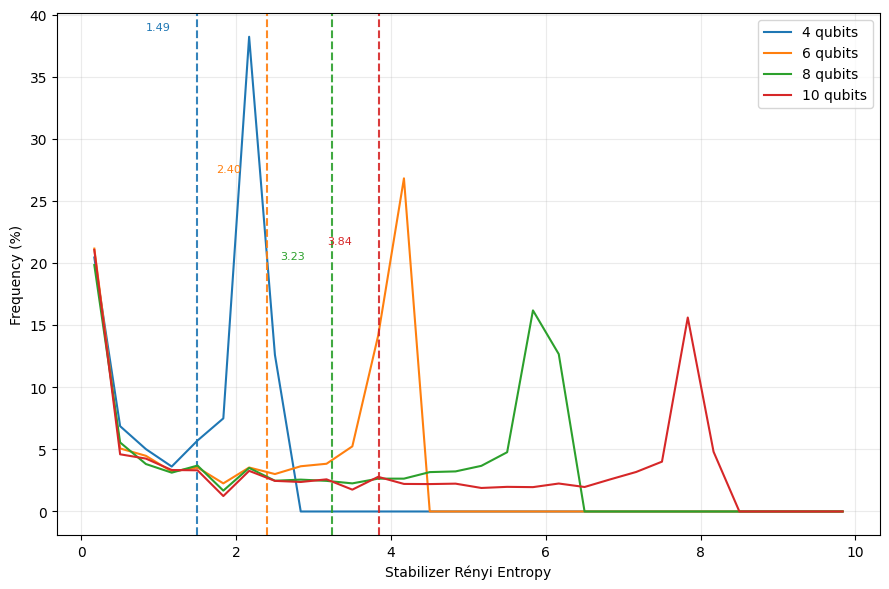

In [17]:
_plot_SRE_distribution(base_dataset_cliff, value_range=(0, 9))

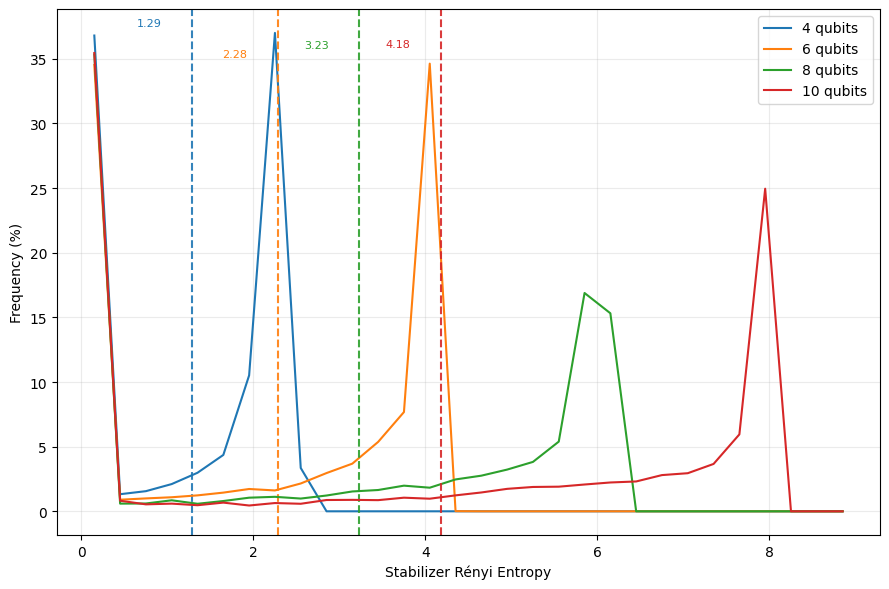

In [18]:
_plot_SRE_distribution(base_dataset_random, value_range=(0, 9))

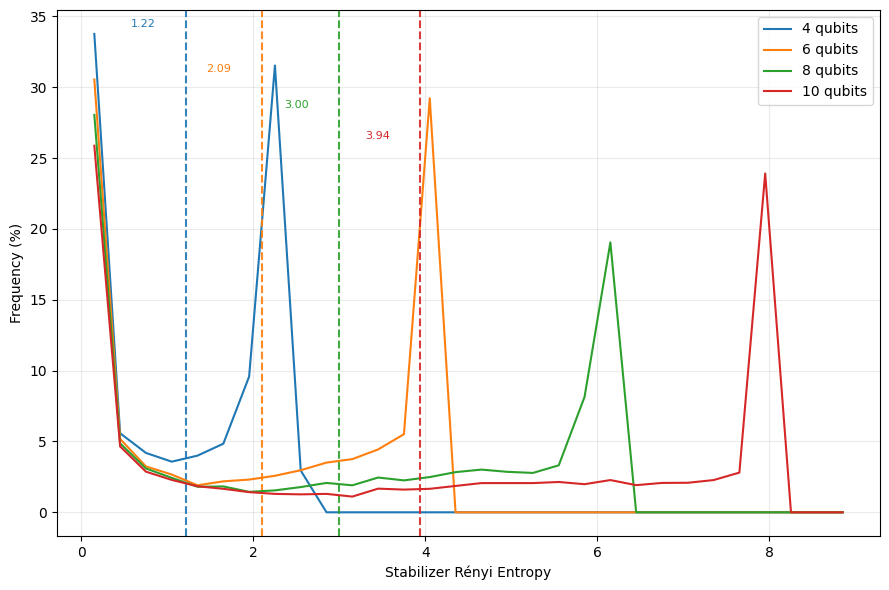

In [19]:
_plot_SRE_distribution(base_dataset_haar, value_range=(0, 9))

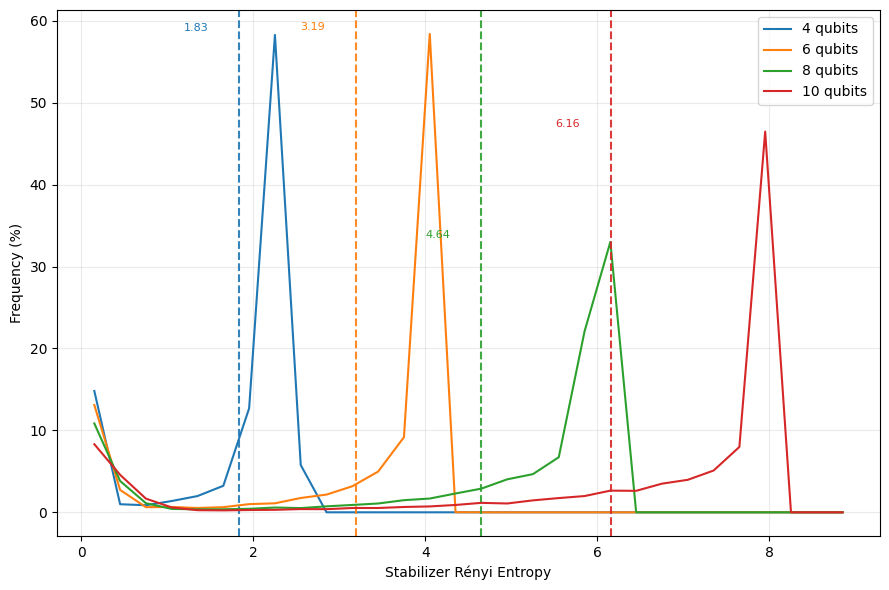

In [20]:
_plot_SRE_distribution(base_dataset_quansistor, value_range=(0, 9))

## Test datasets

In [25]:
import numpy as np

from qqe.src.GNN.dataset_builder import (
    DataGenConfig,
    RegimeDistribution,
    SamplingConfig,
    run_dataset_pipeline,
)
PROJECT_ROOT = Path().resolve().parent

In [28]:
def default_sampling_config() -> SamplingConfig:
    return SamplingConfig(
        clifford=RegimeDistribution(
            regimes=["zero", "low", "medium", "high"],
            probabilities=[0.10, 0.20, 0.20, 0.50],
        ),
        random=RegimeDistribution(
            regimes=["identity_like", "clifford_like", "small_angles", "generic"],
            probabilities=[0.10, 0.20, 0.20, 0.50],
        ),
        quansistor=RegimeDistribution(
            regimes=[
                "identity_like",
                "weak",
                "moderate",
                "structured_equal_ab",
                "structured_opposite_ab",
                "generic_uniform",
            ],
            probabilities=[0.2, 0.10, 0.10, 0.10, 0.15, 0.35],
        ),
        haar=RegimeDistribution(
            regimes=["none", "sparse_weak", "dense_weak", "sparse_full", "medium", "full"],
            probabilities=[0.10, 0.15, 0.15, 0.15, 0.15, 0.30],
        ),
    )


def test_dataset_builder(
    backend: str = "pennylane",
    target: str = "SRE",
    method: str = "fwht",
    use_dask: bool = True,
    output_dir: str = "outputs/data/test_dataset",
    n_bins_option: int = 50,
    families: str ="quansistor,random,clifford,haar",
    n_seeds_option: int = 75,
    prediction_n_seeds_option: int | None = 5,
    qubits_min: int = 4,
    qubits_max: int = 10,
    qubits_step: int = 2,
    layers_min: int = 2,
    layers_max: int = 100,
    layers_step: int = 2,
    target_qubits: str = "4,6,8,10",
    max_configs: int | None = None,
    dask_n_workers: int = 4,
    dask_memory_per_worker: str = "32GiB",
):
    selected_families = [f.strip() for f in families.split(",") if f.strip()]

    qubits_values = np.arange(qubits_min, qubits_max + 1, qubits_step)
    layers_values = np.concatenate(
        ([1], np.arange(layers_min, layers_max + 1, layers_step)),
    )

    selected_target_qubits = tuple(
        int(q.strip()) for q in target_qubits.split(",") if q.strip()
    )

    target_norm = target.strip().lower()

    compute_sre = target_norm == "sre"
    compute_EE = target_norm == "ee"

    if target_norm not in {"sre", "ee", "none"}:
        raise ValueError("target must be 'SRE', 'EE', or 'none'")

    output_path = PROJECT_ROOT / output_dir.strip("/")

    logger.info(f"Building datasets in {output_path}...")
    config = DataGenConfig(
        backend=backend,
        method=method,
        families=selected_families,
        qubits_values=qubits_values,
        layers_values=layers_values,
        n_seeds=n_seeds_option,
        prediction_n_seeds=prediction_n_seeds_option,
        n_bins=n_bins_option,
        compute_sre=compute_sre,
        compute_EE=compute_EE,
        target_qubits=selected_target_qubits,
        representation="dense",
        use_dask=use_dask,
        dask_n_workers=dask_n_workers,
        dask_memory_per_worker=dask_memory_per_worker,
        output_dir=output_path,
        max_configs=max_configs,
    )

    run_dataset_pipeline(
        config=config,
        families=selected_families,
        qubits_values=qubits_values,
        layers_values=layers_values,
        n_seeds=n_seeds_option,
        use_dask=use_dask,
        max_configs=max_configs,
        dask_n_workers=dask_n_workers,
        dask_memory_per_worker=dask_memory_per_worker,
        sampling_config=default_sampling_config(),
    )

In [29]:
test_dataset_builder()

2026-05-19 11:44:17,948 - __main__ - INFO - Building datasets in C:\Users\Victor\Desktop\Université\Research\qml-quansistor-entropy\qqe\outputs\data\test_dataset...
2026-05-19 11:44:17,949 - qqe.src.GNN.dataset_builder - INFO - Processing family: quansistor
2026-05-19 11:44:17,974 - qqe.src.GNN.dataset_builder - INFO - Generated 15300 configs for quansistor
2026-05-19 11:44:17,976 - qqe.src.parallel.dask - INFO - Creating local Dask cluster with 4 workers, 1 threads per worker.
2026-05-19 11:44:17,999 - distributed.scheduler - INFO - State start
2026-05-19 11:44:18,022 - distributed.scheduler - INFO -   Scheduler at:     tcp://127.0.0.1:57297
2026-05-19 11:44:18,023 - distributed.scheduler - INFO -   dashboard at:  http://127.0.0.1:8787/status
2026-05-19 11:44:18,023 - distributed.scheduler - INFO - Registering Worker plugin shuffle
2026-05-19 11:44:18,044 - distributed.nanny.memory - WARNING - Ignoring provided memory limit 32GiB due to system memory limit of 31.19 GiB
2026-05-19 11:4

In [31]:
data_dir = "../outputs/data/test_dataset"

In [32]:
train_loader_cliff, val_loader_cliff, test_loader_cliff, node_in_dim_cliff, global_in_dim_cliff, base_dataset_cliff = make_dataset_loaders(model_type, epochs, lr, loss_type, batch_size, training_mode, "clifford", target, data_dir, model_save_path, show_progress, show_val_progress, log_every_n_batches, heartbeat_secs, epoch_time_warning_secs)
train_loader_haar, val_loader_haar, test_loader_haar, node_in_dim_haar, global_in_dim_haar, base_dataset_haar = make_dataset_loaders(model_type, epochs, lr, loss_type, batch_size, training_mode, "haar", target, data_dir, model_save_path, show_progress, show_val_progress, log_every_n_batches, heartbeat_secs, epoch_time_warning_secs)
train_loader_random, val_loader_random, test_loader_random, node_in_dim_random, global_in_dim_random, base_dataset_random = make_dataset_loaders(model_type, epochs, lr, loss_type, batch_size, training_mode, "random", target, data_dir, model_save_path, show_progress, show_val_progress, log_every_n_batches, heartbeat_secs, epoch_time_warning_secs)
train_loader_quansistor, val_loader_quansistor, test_loader_quansistor, node_in_dim_quansistor, global_in_dim_quansistor, base_dataset_quansistor = make_dataset_loaders(model_type, epochs, lr, loss_type, batch_size, training_mode, "quansistor", target, data_dir, model_save_path, show_progress, show_val_progress, log_every_n_batches, heartbeat_secs, epoch_time_warning_secs)

2026-05-19 13:22:17,052 - __main__ - INFO - Found 15300 data paths.
2026-05-19 13:22:17,053 - __main__ - INFO - Data paths collected.
2026-05-19 13:22:17,053 - __main__ - INFO - Building loaders and model for model_type=gnn...
2026-05-19 13:22:50,006 - __main__ - INFO - Found 15300 data paths.
2026-05-19 13:22:50,007 - __main__ - INFO - Data paths collected.
2026-05-19 13:22:50,008 - __main__ - INFO - Building loaders and model for model_type=gnn...
2026-05-19 13:23:35,412 - __main__ - INFO - Found 15300 data paths.
2026-05-19 13:23:35,412 - __main__ - INFO - Data paths collected.
2026-05-19 13:23:35,412 - __main__ - INFO - Building loaders and model for model_type=gnn...
2026-05-19 13:24:43,468 - __main__ - INFO - Found 15300 data paths.
2026-05-19 13:24:43,469 - __main__ - INFO - Data paths collected.
2026-05-19 13:24:43,469 - __main__ - INFO - Building loaders and model for model_type=gnn...


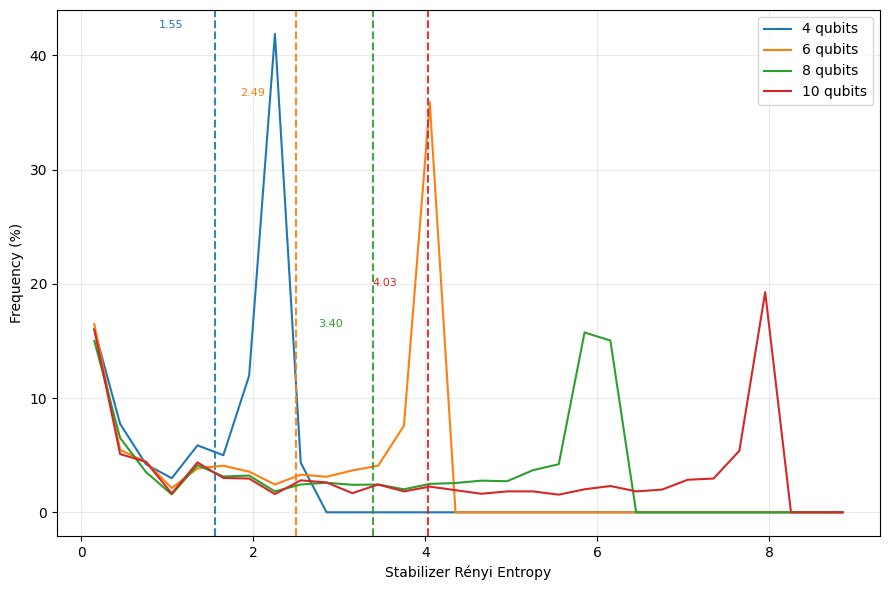

In [33]:
_plot_SRE_distribution(base_dataset_cliff, value_range=(0, 9))

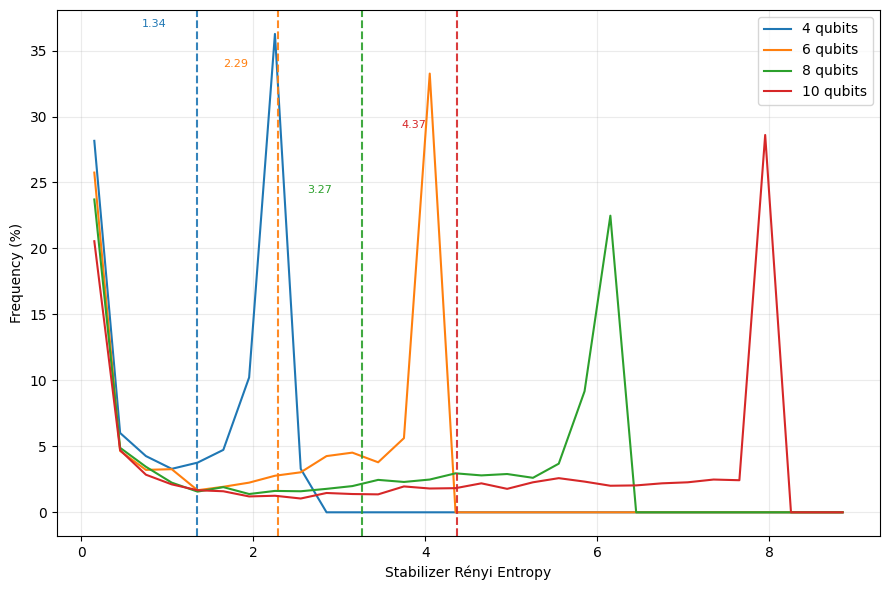

In [34]:
_plot_SRE_distribution(base_dataset_haar, value_range=(0, 9))

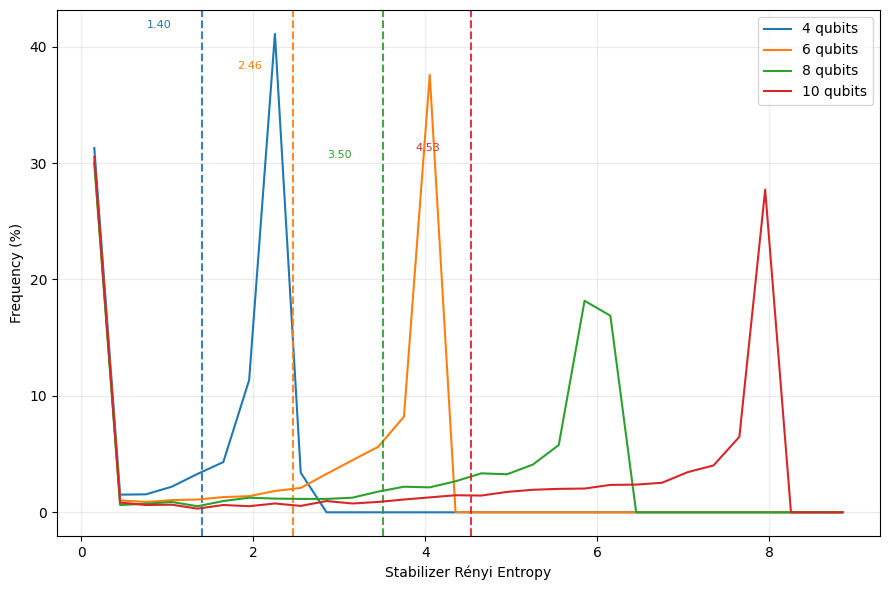

In [35]:
_plot_SRE_distribution(base_dataset_random, value_range=(0, 9))

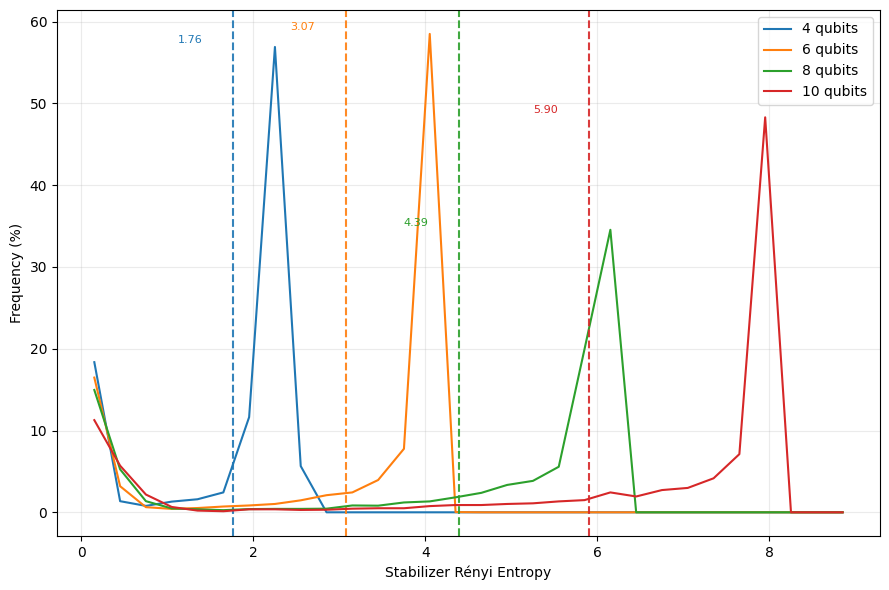

In [36]:
_plot_SRE_distribution(base_dataset_quansistor, value_range=(0, 9))

### Training model

In [5]:
import ast

def to_scalar(x):
    # Already numeric
    if isinstance(x, (int, float)):
        return x

    # torch / numpy scalar
    if hasattr(x, "item"):
        return x.item()

    # Strings
    if isinstance(x, str):
        x = x.strip()

        # Handle tensor(...) by stripping wrapper FIRST
        if x.startswith("tensor(") and x.endswith(")"):
            x = x[len("tensor("):-1].strip()

        try:
            val = ast.literal_eval(x)
        except Exception:
            # fallback: plain float string
            return float(x)

        # If it's a list/tuple like [10]
        if isinstance(val, (list, tuple)):
            if len(val) == 1:
                return float(val[0])
            raise ValueError(f"Unexpected list length: {val}")

        return float(val)

    raise ValueError(f"Unsupported type: {type(x)}")

In [6]:
def run(
    model_type,
    epochs,
    lr,
    loss_type,
    batch_size,
    training_mode,
    family,
    target,
    model_hparams,
    train_hparams,
    training_data_dir,
    model_save_path,
):
    training(
        epochs=epochs,
        lr=lr,
        loss_type=loss_type,
        batch_size=batch_size,
        training_mode=training_mode,
        family=family,
        target=target,
        model_type=model_type,
        model_hparams=model_hparams,
        train_hparams=train_hparams,
        training_data_dir=training_data_dir,
        model_save_path=model_save_path,
        show_progress=True,
        show_val_progress=False,
        log_every_n_batches=10,
        heartbeat_secs=60.0,
        epoch_time_warning_secs=600.0,
    )
    training_scope = "family" if training_mode == "per_family" else "global"
    predictions(
        model_path=model_save_path,
        model_kind=model_type,
        training_scope=training_scope,
        loss_type=loss_type,
        model_family=family,
        dataset_root=training_data_dir,
        dataset_family=family,
        batch_size=batch_size,
        global_feature_variant="binned",
        node_feature_backend_variant=None,
        plot_n_layers=10,
        plot_n_qubits=18,
        split_by_family=True,
        show_progress=True,
    )

    df = pd.read_csv(f"../outputs/predictions/{training_scope}/{model_type}_predictions_{family}.csv")
    cols_to_fix = ["n_qubits", "n_layers", "seed"]

    for col in cols_to_fix:
        df[col] = df[col].apply(to_scalar).astype(int)
    view_correlation(
        df,
        nq=10,
        nl=80,
        col_x="target",
        col_y="prediction",
    )

In [43]:
model_type="gnn"
epochs = 30
lr = 4.713739768368574e-05
loss_type = "mse"   # "mse" | "huber"
batch_size = 16
training_mode = "per_family"  # "global" | "per_family"
family = "clifford"  # required if training_mode == "per_family"
target = "sre"
data_dir = "../outputs/data/dataset"
model_save_path = "../outputs/models/test_clifford_model_gnn.pt"
show_progress=True
show_val_progress=False
log_every_n_batches=10
heartbeat_secs=60.0
epoch_time_warning_secs=600.0


model_hparams = {
    "gnn_hidden": 32,
    "gnn_heads": 4,
    "global_hidden": 64,
    "reg_hidden": 16,
    "num_layers": 6,
    "dropout_rate": 0.16706832478693956,
}

train_hparams = {
    "weight_decay": 0.0003546212126918109,
    "grad_clip": 0.031369743908464774,
    "early_stopping_patience": 10,
    "early_stopping_min_delta": 0.0,
}

2026-05-19 14:04:03,477 - qqe.src.GNN.training.runners - INFO - Starting training | model_type=gnn | training_mode=per_family | family=clifford | loss_type=mse
2026-05-19 14:04:03,478 - qqe.src.GNN.training.runners - INFO - Training configuration done.
2026-05-19 14:04:03,479 - qqe.src.GNN.training.runners - INFO - Collecting data paths...
2026-05-19 14:06:17,070 - qqe.src.GNN.training.runners - INFO - Found 35700 data paths.
2026-05-19 14:06:17,071 - qqe.src.GNN.training.runners - INFO - Data paths collected.
2026-05-19 14:06:17,072 - qqe.src.GNN.training.runners - INFO - Building loaders and model for model_type=gnn...
2026-05-19 14:07:13,185 - qqe.src.GNN.training.runners - INFO - Loaders and model built.
2026-05-19 14:07:13,185 - qqe.src.GNN.training.runners - INFO - Starting training...
2026-05-19 14:07:13,378 - qqe.src.GNN.training.train - INFO - -------- EPOCH 001 --------


Epoch 1/30:  96%|█████████▋| 1548/1607 [01:00<00:02, 27.21it/s, loss=4.8264, graphs=24800]

2026-05-19 14:08:13,392 - qqe.src.GNN.training.train - INFO - [Heartbeat] Epoch 1 batch 1550/1607 | loss 4.826364 | elapsed 60.0s | graphs 24800


2026-05-19 14:08:16,106 - qqe.src.GNN.training.train - INFO - Training complete (62.7s) | running validation...


2026-05-19 14:08:20,910 - qqe.src.GNN.training.train - INFO - Losses | train 4.780839 | val 2.224123 | lr 4.71e-05 | time train=62.7s val=4.8s total=67.5s
2026-05-19 14:08:20,914 - qqe.src.GNN.training.train - INFO - -------- EPOCH 002 --------


...

2026-05-19 14:27:48,878 - qqe.src.GNN.training.train - INFO - Losses | train 1.288698 | val 0.918605 | lr 2.36e-05 | time train=65.7s val=5.0s total=70.7s
2026-05-19 14:27:48,878 - qqe.src.GNN.training.train - INFO - -------- EPOCH 019 --------


Epoch 19/30:  91%|█████████▏| 1470/1607 [01:00<00:05, 25.47it/s, loss=1.2854, graphs=23568]

2026-05-19 14:28:48,904 - qqe.src.GNN.training.train - INFO - [Heartbeat] Epoch 19 batch 1473/1607 | loss 1.285431 | elapsed 60.0s | graphs 23568


2026-05-19 14:28:54,359 - qqe.src.GNN.training.train - INFO - Training complete (65.5s) | running validation...


2026-05-19 14:28:59,213 - qqe.src.GNN.training.train - INFO - Losses | train 1.289484 | val 0.901604 | lr 2.36e-05 | time train=65.5s val=4.9s total=70.3s
2026-05-19 14:28:59,213 - qqe.src.GNN.training.train - INFO - Early stopping at epoch 019 | best val 0.877521 | patience exhausted (10/10)
2026-05-19 14:29:12,280 - qqe.src.GNN.training.runners - INFO - Training complete.


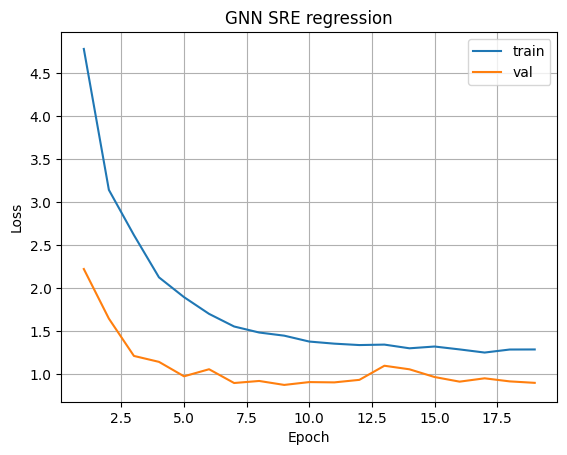

2026-05-19 14:29:12,417 - qqe.src.GNN.training.runners - INFO - Saved model checkpoint to ../outputs/models/test_clifford_model_gnn.pt
2026-05-19 14:29:12,422 - scripts.train_model - INFO - Final test loss: 0.853011
2026-05-19 14:29:12,424 - scripts.predictions - INFO - Loading checkpoint: ../outputs/models/test_clifford_model_gnn.pt
2026-05-19 14:29:47,355 - scripts.predictions - INFO - Found 124950 prediction files
Predicting (gnn): 100%|██████████| 7810/7810 [05:38<00:00, 23.06batch/s]
2026-05-19 14:35:34,209 - scripts.predictions - INFO - Saved 124950 predictions to ../outputs/predictions/family/gnn_predictions_clifford.csv
2026-05-19 14:35:34,397 - scripts.predictions - INFO - Saved fixed-layer plot to ../outputs/figures/predictions/family/gnn_pred_layers_clifford.png
2026-05-19 14:35:34,594 - scripts.predictions - INFO - Saved fixed-qubit plot to ../outputs/figures/predictions/family/gnn_pred_qubits_clifford.png


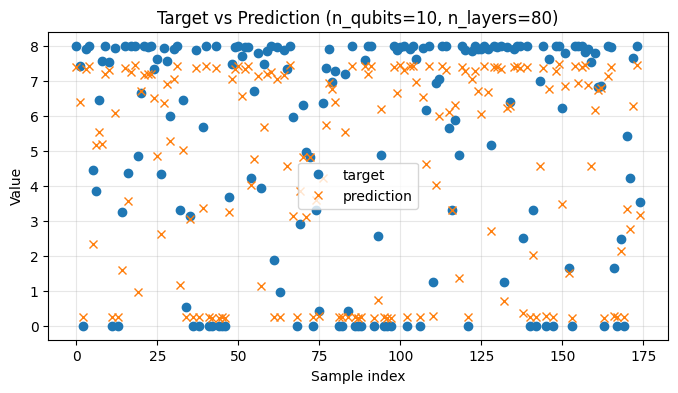

Pearson r = 0.9592


In [44]:
run(
    model_type=model_type,
    epochs=epochs,
    lr=lr,
    loss_type=loss_type,
    batch_size=batch_size,
    training_mode=training_mode,
    family=family,
    target=target,
    model_hparams=model_hparams,
    train_hparams=train_hparams,
    training_data_dir=data_dir,
    model_save_path=model_save_path,
)

In [ ]:
model_type="gnn"
epochs = 30
lr = 4.713739768368574e-05
loss_type = "mse"   # "mse" | "huber"
batch_size = 32
training_mode = "per_family"  # "global" | "per_family"
family = "random"  # required if training_mode == "per_family"
target = "sre"
data_dir = "../outputs/data/dataset"
model_save_path = f"../outputs/models/test_{family}_model_{model_type}.pt"
show_progress=True
show_val_progress=False
log_every_n_batches=10
heartbeat_secs=60.0
epoch_time_warning_secs=600.0


model_hparams = {
    "gnn_hidden": 32,
    "gnn_heads": 4,
    "global_hidden": 64,
    "reg_hidden": 16,
    "num_layers": 6,
    "dropout_rate": 0.16706832478693956,
}

train_hparams = {
    "weight_decay": 0.0003546212126918109,
    "grad_clip": 0.031369743908464774,
    "early_stopping_patience": 10,
    "early_stopping_min_delta": 0.0,
}

2026-05-19 14:35:38,516 - qqe.src.GNN.training.runners - INFO - Starting training | model_type=gnn | training_mode=per_family | family=random | loss_type=mse
2026-05-19 14:35:38,516 - qqe.src.GNN.training.runners - INFO - Training configuration done.
2026-05-19 14:35:38,518 - qqe.src.GNN.training.runners - INFO - Collecting data paths...
2026-05-19 14:37:55,861 - qqe.src.GNN.training.runners - INFO - Found 35700 data paths.
2026-05-19 14:37:55,862 - qqe.src.GNN.training.runners - INFO - Data paths collected.
2026-05-19 14:37:55,863 - qqe.src.GNN.training.runners - INFO - Building loaders and model for model_type=gnn...
2026-05-19 14:39:33,758 - qqe.src.GNN.training.runners - INFO - Loaders and model built.
2026-05-19 14:39:33,759 - qqe.src.GNN.training.runners - INFO - Starting training...
2026-05-19 14:39:33,770 - qqe.src.GNN.training.train - INFO - -------- EPOCH 001 --------


Epoch 1/30:  59%|█████▉    | 955/1607 [01:00<00:44, 14.53it/s, loss=6.8961, graphs=15296]

2026-05-19 14:40:33,827 - qqe.src.GNN.training.train - INFO - [Heartbeat] Epoch 1 batch 956/1607 | loss 6.896085 | elapsed 60.1s | graphs 15296


2026-05-19 14:41:13,688 - qqe.src.GNN.training.train - INFO - Training complete (99.9s) | running validation...


2026-05-19 14:41:22,242 - qqe.src.GNN.training.train - INFO - Losses | train 5.356569 | val 1.697485 | lr 4.71e-05 | time train=99.9s val=8.6s total=108.5s
2026-05-19 14:41:22,245 - qqe.src.GNN.training.train - INFO - -------- EPOCH 002 --------


...

2026-05-19 15:44:42,363 - qqe.src.GNN.training.train - INFO - [Heartbeat] Epoch 30 batch 706/1607 | loss 1.018124 | elapsed 60.0s | graphs 11296


Epoch 30/30:  85%|████████▌ | 1368/1607 [02:00<00:22, 10.73it/s, loss=1.0281, graphs=21904]

2026-05-19 15:45:42,388 - qqe.src.GNN.training.train - INFO - [Heartbeat] Epoch 30 batch 1369/1607 | loss 1.028105 | elapsed 120.0s | graphs 21904


2026-05-19 15:46:03,239 - qqe.src.GNN.training.train - INFO - Training complete (140.9s) | running validation...


2026-05-19 15:46:14,468 - qqe.src.GNN.training.train - INFO - Losses | train 1.016126 | val 0.306465 | lr 4.71e-05 | time train=140.9s val=11.2s total=152.1s
2026-05-19 15:46:47,209 - qqe.src.GNN.training.runners - INFO - Training complete.


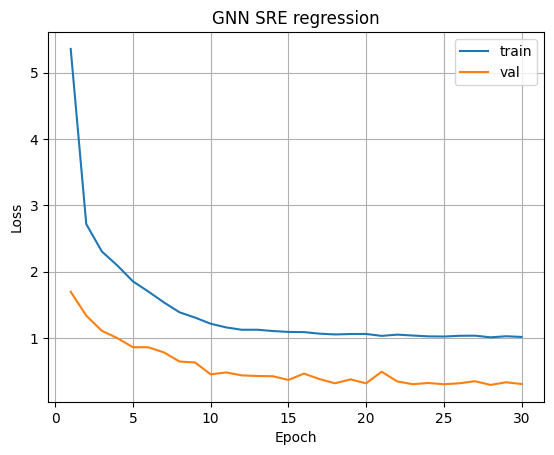

2026-05-19 15:46:47,374 - qqe.src.GNN.training.runners - INFO - Saved model checkpoint to ../outputs/models/test_random_model_gnn.pt
2026-05-19 15:46:47,380 - scripts.train_model - INFO - Final test loss: 0.291363
2026-05-19 15:46:47,382 - scripts.predictions - INFO - Loading checkpoint: ../outputs/models/test_random_model_gnn.pt
2026-05-19 15:47:32,358 - scripts.predictions - INFO - Found 124950 prediction files
Predicting (gnn): 100%|██████████| 7810/7810 [15:08<00:00,  8.60batch/s]
2026-05-19 16:02:53,086 - scripts.predictions - INFO - Saved 124950 predictions to ../outputs/predictions/family/gnn_predictions_random.csv
2026-05-19 16:02:53,331 - scripts.predictions - INFO - Saved fixed-layer plot to ../outputs/figures/predictions/family/gnn_pred_layers_random.png
2026-05-19 16:02:53,610 - scripts.predictions - INFO - Saved fixed-qubit plot to ../outputs/figures/predictions/family/gnn_pred_qubits_random.png


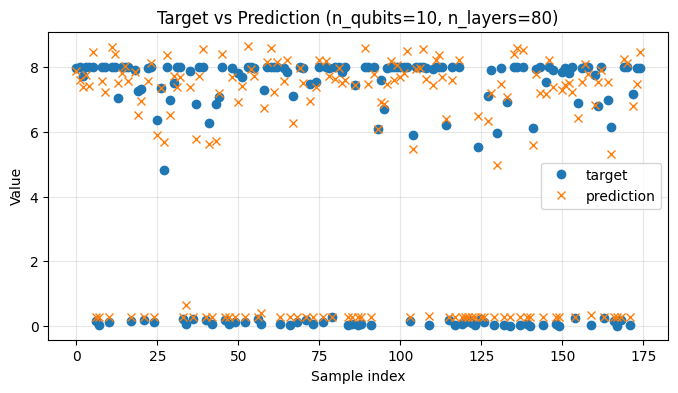

Pearson r = 0.9938


In [46]:
run(
    model_type=model_type,
    epochs=epochs,
    lr=lr,
    loss_type=loss_type,
    batch_size=batch_size,
    training_mode=training_mode,
    family=family,
    target=target,
    model_hparams=model_hparams,
    train_hparams=train_hparams,
    training_data_dir=data_dir,
    model_save_path=model_save_path,
)

2026-05-20 13:37:42,526 - qqe.src.GNN.training.runners - INFO - Starting training | model_type=gnn | training_mode=global | family=random | loss_type=mse
2026-05-20 13:37:42,529 - qqe.src.GNN.training.runners - INFO - Training configuration done.
2026-05-20 13:37:42,529 - qqe.src.GNN.training.runners - INFO - Collecting data paths...
2026-05-20 13:46:58,438 - qqe.src.GNN.training.runners - INFO - Found 142800 data paths.
2026-05-20 13:46:58,439 - qqe.src.GNN.training.runners - INFO - Data paths collected.
2026-05-20 13:46:58,439 - qqe.src.GNN.training.runners - INFO - Building loaders and model for model_type=gnn...
2026-05-20 13:52:20,568 - qqe.src.GNN.training.runners - INFO - Loaders and model built.
2026-05-20 13:52:20,568 - qqe.src.GNN.training.runners - INFO - Starting training...
2026-05-20 13:52:20,770 - qqe.src.GNN.training.train - INFO - -------- EPOCH 001 --------


Epoch 1/30:  17%|█▋        | 1114/6426 [01:00<04:52, 18.14it/s, loss=7.9713, graphs=17856]

2026-05-20 13:53:20,806 - qqe.src.GNN.training.train - INFO - [Heartbeat] Epoch 1 batch 1116/6426 | loss 7.971349 | elapsed 60.0s | graphs 17856


Epoch 1/30:  35%|███▍      | 2226/6426 [02:00<03:44, 18.69it/s, loss=5.8838, graphs=35648]

2026-05-20 13:54:20,836 - qqe.src.GNN.training.train - INFO - [Heartbeat] Epoch 1 batch 2228/6426 | loss 5.883781 | elapsed 120.1s | graphs 35648


...

2026-05-20 16:45:10,642 - qqe.src.GNN.training.train - INFO - [Heartbeat] Epoch 28 batch 4552/6426 | loss 1.399692 | elapsed 240.1s | graphs 72832


Epoch 28/30:  89%|████████▊ | 5693/6426 [05:00<00:39, 18.38it/s, loss=1.4004, graphs=91104]

2026-05-20 16:46:10,679 - qqe.src.GNN.training.train - INFO - [Heartbeat] Epoch 28 batch 5694/6426 | loss 1.400408 | elapsed 300.1s | graphs 91104


2026-05-20 16:46:49,387 - qqe.src.GNN.training.train - INFO - Training complete (338.8s) | running validation...


2026-05-20 16:47:19,342 - qqe.src.GNN.training.train - INFO - Losses | train 1.398229 | val 0.694088 | lr 2.36e-05 | time train=338.8s val=30.0s total=368.8s
2026-05-20 16:47:19,343 - qqe.src.GNN.training.train - INFO - Early stopping at epoch 028 | best val 0.690906 | patience exhausted (10/10)
2026-05-20 16:48:55,388 - qqe.src.GNN.training.runners - INFO - Training complete.


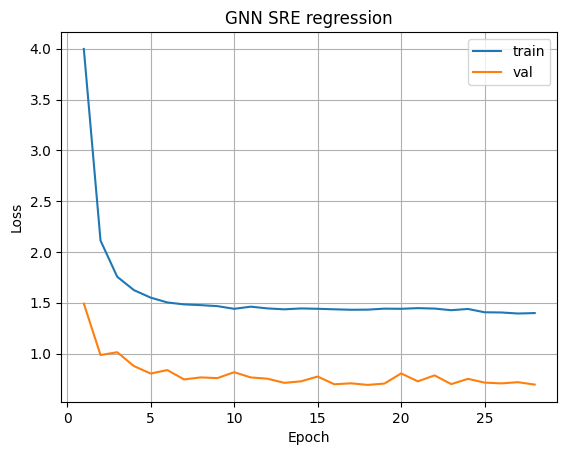

2026-05-20 16:48:55,750 - qqe.src.GNN.training.runners - INFO - Saved model checkpoint to ../outputs/models/test_random_model_gnn_global.pt
2026-05-20 16:48:55,756 - scripts.train_model - INFO - Final test loss: 0.688472
2026-05-20 16:48:55,758 - scripts.predictions - INFO - Loading checkpoint: ../outputs/models/test_random_model_gnn_global.pt
2026-05-20 16:49:30,154 - scripts.predictions - INFO - Found 124950 prediction files
Predicting (gnn): 100%|██████████| 7810/7810 [30:10<00:00,  4.31batch/s]
2026-05-20 17:19:49,581 - scripts.predictions - INFO - Saved 124950 predictions to ../outputs/predictions/global/gnn_predictions_random.csv
2026-05-20 17:19:49,765 - scripts.predictions - INFO - Saved fixed-layer plot to ../outputs/figures/predictions/global/gnn_pred_layers_random.png
2026-05-20 17:19:49,965 - scripts.predictions - INFO - Saved fixed-qubit plot to ../outputs/figures/predictions/global/gnn_pred_qubits_random.png


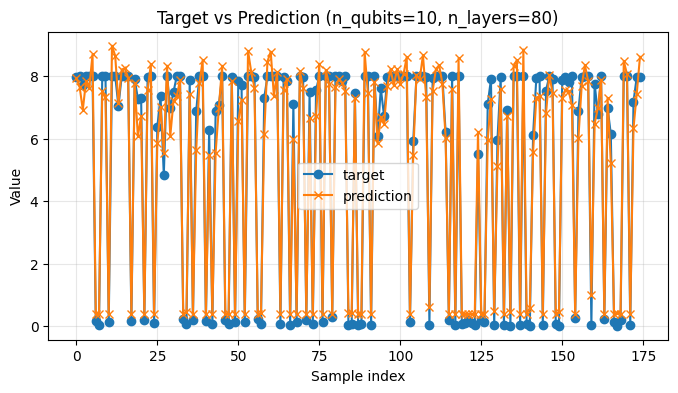

Pearson r = 0.9908


In [7]:
model_type="gnn"
epochs = 30
lr = 4.713739768368574e-05
loss_type = "mse"   # "mse" | "huber"
batch_size = 16
training_mode = "global"  # "global" | "per_family"
family = "random"  # required if training_mode == "per_family"
target = "sre"
data_dir = "../outputs/data/dataset"
model_save_path = f"../outputs/models/test_{family}_model_{model_type}_{training_mode}.pt"
show_progress=True
show_val_progress=False
log_every_n_batches=10
heartbeat_secs=60.0
epoch_time_warning_secs=600.0


model_hparams = {
    "gnn_hidden": 32,
    "gnn_heads": 4,
    "global_hidden": 64,
    "reg_hidden": 16,
    "num_layers": 6,
    "dropout_rate": 0.16706832478693956,
}

train_hparams = {
    "weight_decay": 0.0003546212126918109,
    "grad_clip": 0.031369743908464774,
    "early_stopping_patience": 10,
    "early_stopping_min_delta": 0.0,
}

run(
    model_type=model_type,
    epochs=epochs,
    lr=lr,
    loss_type=loss_type,
    batch_size=batch_size,
    training_mode=training_mode,
    family=family,
    target=target,
    model_hparams=model_hparams,
    train_hparams=train_hparams,
    training_data_dir=data_dir,
    model_save_path=model_save_path,
)

In [4]:
import matplotlib.pyplot as plt
import pandas as pd
import ast

from qqe.src.experiments.plotting import view_correlation

def to_scalar(x):
    # Already numeric
    if isinstance(x, (int, float)):
        return x

    # torch / numpy scalar
    if hasattr(x, "item"):
        return x.item()

    # Strings
    if isinstance(x, str):
        x = x.strip()

        # Handle tensor(...) by stripping wrapper FIRST
        if x.startswith("tensor(") and x.endswith(")"):
            x = x[len("tensor("):-1].strip()

        try:
            val = ast.literal_eval(x)
        except Exception:
            # fallback: plain float string
            return float(x)

        # If it's a list/tuple like [10]
        if isinstance(val, (list, tuple)):
            if len(val) == 1:
                return float(val[0])
            raise ValueError(f"Unexpected list length: {val}")

        return float(val)

    raise ValueError(f"Unsupported type: {type(x)}")

In [5]:
cliff_df = pd.read_csv("../outputs/predictions/global/gnn_predictions_random.csv")

In [6]:
cols_to_fix = ["n_qubits", "n_layers", "seed"]

for col in cols_to_fix:
    cliff_df[col] = cliff_df[col].apply(to_scalar).astype(int)

In [11]:
cliff_q_l = cliff_df.copy()
cliff_q_l = cliff_q_l[(cliff_q_l["n_qubits"] == 4) & (cliff_q_l["n_layers"] == 50)]

Text(0.5, 1.0, 'True vs Predicted SRE for Clifford Family (GNN Model)')

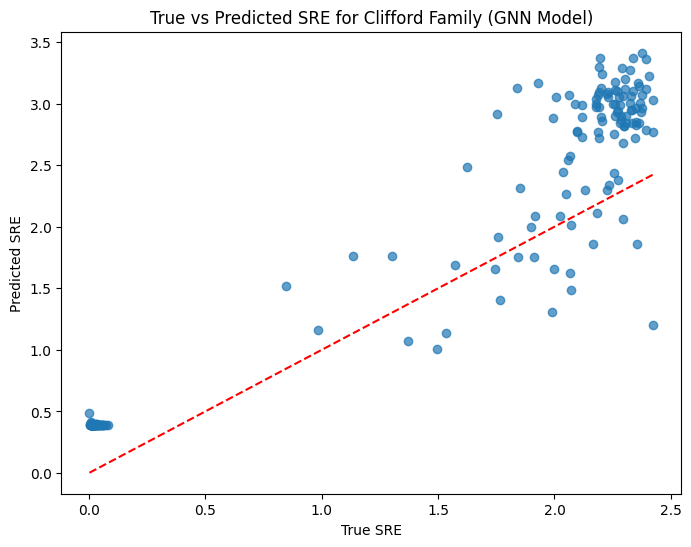

In [12]:
plt.figure(figsize=(8, 6))
plt.scatter(cliff_q_l["target"], cliff_q_l["prediction"], alpha=0.7)
plt.plot([cliff_q_l["target"].min(), cliff_q_l["target"].max()], [cliff_q_l["target"].min(), cliff_q_l["target"].max()], 'r--')  # y=x line
plt.xlabel("True SRE")
plt.ylabel("Predicted SRE")
plt.title("True vs Predicted SRE for Clifford Family (GNN Model)")

In [ ]:
model_type="gnn"
epochs = 30
lr = 4.713739768368574e-05
loss_type = "huber"   # "mse" | "huber"
batch_size = 16
training_mode = "global"  # "global" | "per_family"
family = "random"  # required if training_mode == "per_family"
target = "sre"
data_dir = "../outputs/data/test_dataset"
model_save_path = f"../outputs/models/test_{family}_model_{model_type}_{training_mode}.pt"
show_progress=True
show_val_progress=False
log_every_n_batches=10
heartbeat_secs=60.0
epoch_time_warning_secs=600.0


model_hparams = {
    "gnn_hidden": 32,
    "gnn_heads": 4,
    "global_hidden": 64,
    "reg_hidden": 16,
    "num_layers": 6,
    "dropout_rate": 0.16706832478693956,
}

train_hparams = {
    "weight_decay": 0.0003546212126918109,
    "grad_clip": 0.031369743908464774,
    "early_stopping_patience": 10,
    "early_stopping_min_delta": 0.0,
}

run(
    model_type=model_type,
    epochs=epochs,
    lr=lr,
    loss_type=loss_type,
    batch_size=batch_size,
    training_mode=training_mode,
    family=family,
    target=target,
    model_hparams=model_hparams,
    train_hparams=train_hparams,
    training_data_dir=data_dir,
    model_save_path=model_save_path,
)

2026-05-20 13:34:31,799 - autoreload - ERROR - Failed to reload module 'traitlets.utils.bunch' from file 'c:\Users\Victor\Desktop\Université\Research\qml-quansistor-entropy\.venv\Lib\site-packages\traitlets\utils\bunch.py'
Traceback (most recent call last):
  File "c:\Users\Victor\Desktop\Université\Research\qml-quansistor-entropy\.venv\Lib\site-packages\IPython\extensions\autoreload.py", line 325, in check
    superreload(m, reload, self.old_objects)
  File "c:\Users\Victor\Desktop\Université\Research\qml-quansistor-entropy\.venv\Lib\site-packages\IPython\extensions\autoreload.py", line 625, in superreload
    update_generic(old_obj, new_obj)
  File "c:\Users\Victor\Desktop\Université\Research\qml-quansistor-entropy\.venv\Lib\site-packages\IPython\extensions\autoreload.py", line 451, in update_generic
    update(a, b)
  File "c:\Users\Victor\Desktop\Université\Research\qml-quansistor-entropy\.venv\Lib\site-packages\IPython\extensions\autoreload.py", line 403, in update_class
    if up